## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [95]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

import models
import lossCalculator
import correlator
import tensorflow as tf

In [96]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
epsilon = 0#1e-3
omega = np.linspace(epsilon,19.96+epsilon,501)
del_omega = omega[1]-omega[0]
omega=omega[1:]

In [97]:
omega

array([ 0.03992,  0.07984,  0.11976,  0.15968,  0.1996 ,  0.23952,
        0.27944,  0.31936,  0.35928,  0.3992 ,  0.43912,  0.47904,
        0.51896,  0.55888,  0.5988 ,  0.63872,  0.67864,  0.71856,
        0.75848,  0.7984 ,  0.83832,  0.87824,  0.91816,  0.95808,
        0.998  ,  1.03792,  1.07784,  1.11776,  1.15768,  1.1976 ,
        1.23752,  1.27744,  1.31736,  1.35728,  1.3972 ,  1.43712,
        1.47704,  1.51696,  1.55688,  1.5968 ,  1.63672,  1.67664,
        1.71656,  1.75648,  1.7964 ,  1.83632,  1.87624,  1.91616,
        1.95608,  1.996  ,  2.03592,  2.07584,  2.11576,  2.15568,
        2.1956 ,  2.23552,  2.27544,  2.31536,  2.35528,  2.3952 ,
        2.43512,  2.47504,  2.51496,  2.55488,  2.5948 ,  2.63472,
        2.67464,  2.71456,  2.75448,  2.7944 ,  2.83432,  2.87424,
        2.91416,  2.95408,  2.994  ,  3.03392,  3.07384,  3.11376,
        3.15368,  3.1936 ,  3.23352,  3.27344,  3.31336,  3.35328,
        3.3932 ,  3.43312,  3.47304,  3.51296,  3.55288,  3.59

In [98]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)

# # plt.plot(omega,spec1BW,label=r'1 BW peak')
# plt.plot(omega,spec2BW, label=r'2 BW peaks')
# #plt.plot(omega,spec3BW, label=r'3 BW peaks')

# plt.legend()
# plt.xlim(0,10)


In [99]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

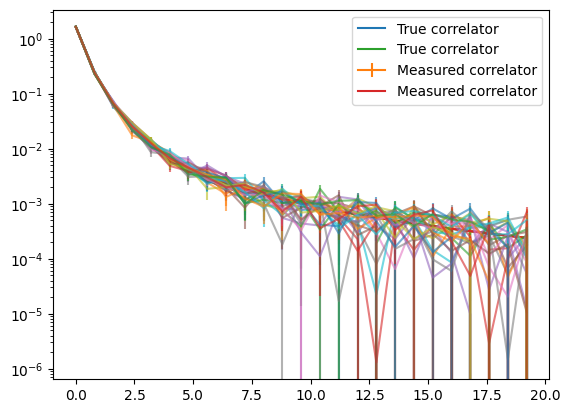

In [100]:
# Preparing the tensor of noise vectors
ep_noise=0#3e-2
noisy_dxi_tensor = []
num_samples = 30
noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi,custom_std, label=r'Measured correlator')
ep_noise=3e-2
if num_samples == 1:
    noisy_dxi_tensor.append(noisy_Dxi)
else:
    for ii in range(num_samples):
        noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
        noisy_dxi_tensor.append(noisy_Dxi_sample)


plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi, label=r'Measured correlator')
# plt.plot(x,noisy_Dxi, label=r'Noisy correlator')
for i in range(len(noisy_dxi_tensor)):
    plt.errorbar(x, noisy_dxi_tensor[i],custom_std,  alpha=0.6)

plt.yscale('log')

plt.legend()

In [101]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop
from multiprocessing import Pool


# Create input data and target
 # Constant input node which goes to 500 omegas as the NN structure in paper
# target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 0#1.0e-6
lambda_l2_warmup = 0#1.0e-6
lambda_s = 0#1.0e-5
lambda_l2 = 0#1.0e-9
lambda_rho_zero = 0#1e8#1.0e-6
lambda_rho_zero_warmup = 0#1e5#1.0e-6
epochs=2000
new_epochs = 10000

# num_samples = 30
gauss_width = np.ones(len(x)) #for mean square error
gauss_width=custom_std

constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
constant_input = tf.constant(omega, dtype=tf.float32)  #NNP2p
constant_input = tf.reshape(constant_input, (-1, 1)) #NNP2p
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
kern=klW_ker_Pos
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)
ep_noise=3e-2
# noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)

model = models.SpectralNNP2P(num_output_nodes=500, width=500, depth=3)
# target_output = tf.constant(noisy_Dxi, dtype=tf.float32)
target_output=noisy_dxi_tensor
lossCalc=lossCalculator.LossCalculator(model=model,
                                    y_true=target_output,
                                    kernel=kern,
                                    delomega=del_omega,
                                    x=constant_input,
                                    std=gauss_width,
                                    lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                    lambda_s_func=lambda x:lambda_s,
                                    lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                    lambda_l2_func=lambda x:lambda_l2,
                                    lambda_rho_zero_func=lambda x:lambda_rho_zero,
                                    lambda_rho_zero_func_warmup=lambda x:lambda_rho_zero_warmup,
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
trainer=models.networkTrainer(model,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4)
trainer=models.networkTrainer(model,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

# optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6) #notice the lower learning rate
# trainer.optimizer=optimizer
# total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)
rho=model(constant_input)








Training for 2000 epochs
Epoch 0, Loss: 475.05120849609375
Epoch 200, Loss: 0.10849908739328384
Epoch 400, Loss: 0.10838005691766739
Epoch 600, Loss: 0.10823100805282593
Epoch 800, Loss: 0.10807342827320099
Epoch 1000, Loss: 0.107933409512043
Epoch 1200, Loss: 0.10782816261053085
Epoch 1400, Loss: 0.10774970799684525
Epoch 1600, Loss: 0.10767525434494019
Epoch 1800, Loss: 0.10758763551712036
Training took 53.663541078567505 seconds
Training for 2000 epochs
Epoch 0, Loss: 0.10747621953487396
Epoch 200, Loss: 0.000657737604342401
Epoch 400, Loss: 0.00041339683230035007
Epoch 600, Loss: 0.0002772397128865123
Epoch 800, Loss: 0.00018818567332345992
Epoch 1000, Loss: 0.00013210259203333408
Epoch 1200, Loss: 9.703535761218518e-05
Epoch 1400, Loss: 8.073660865193233e-05
Epoch 1600, Loss: 7.631132029928267e-05
Epoch 1800, Loss: 0.00010424890933791175
Training took 53.50281357765198 seconds
Training for 10000 epochs
Epoch 0, Loss: 7.098197966115549e-05
Epoch 1000, Loss: 4.751380402012728e-05
Ep

In [19]:
additional_epochs= 20000
optimizer=tf.keras.optimizers.Adam(learning_rate=5e-7) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history_additional,loss_history_additional=trainer.train(additional_epochs,warmup=False,verbose=True)
rho_additional=model(constant_input)


Training for 20000 epochs
Epoch 0, Loss: 3.824671875918284e-05
Epoch 2000, Loss: 3.8195212255232036e-05
Epoch 4000, Loss: 3.814524461631663e-05
Epoch 6000, Loss: 3.809981717495248e-05
Epoch 8000, Loss: 3.805855885730125e-05
Epoch 10000, Loss: 3.8021124055376276e-05
Epoch 12000, Loss: 3.798710895352997e-05
Epoch 14000, Loss: 3.795614611590281e-05
Epoch 16000, Loss: 3.792810457525775e-05
Epoch 18000, Loss: 3.790241316892207e-05
Training took 265.7789282798767 seconds


In [ ]:
# np.save('data/rho_Multifit_30_corrs_rhoFit',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_rhoFit',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_rhoFit',loss_history)

In [22]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

/tmp/ipykernel_30432/2026597341.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0.5, 1.0, 'Single fit ensemble vs Multifit, 30 correlators, NNP2P')

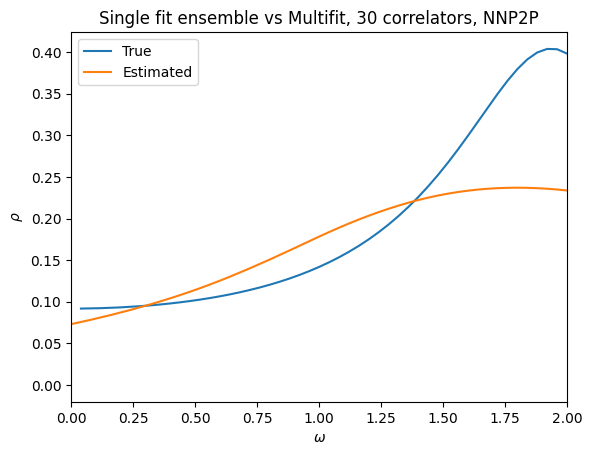

In [20]:
# Multfit result with 30 correlators
# rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')
plt.title('Single fit ensemble vs Multifit, 30 correlators, NNP2P')

Text(0.5, 1.0, 'Single fit ensemble vs Multifit, 30 correlators, NNP2P')

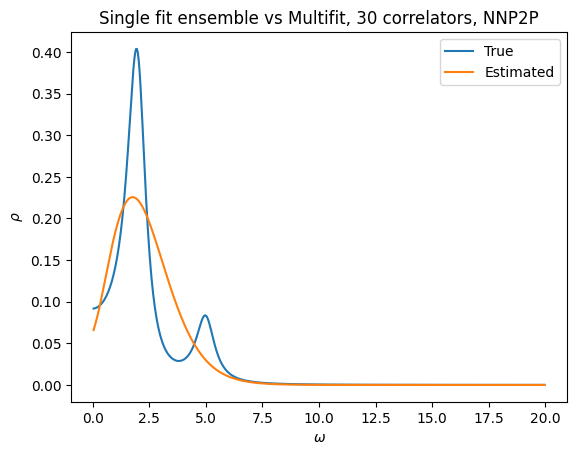

In [104]:
# Multfit result with 30 correlators
# rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
# plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')
plt.title('Single fit ensemble vs Multifit, 30 correlators, NNP2P')

Text(0, 0.5, '$\\rho$')

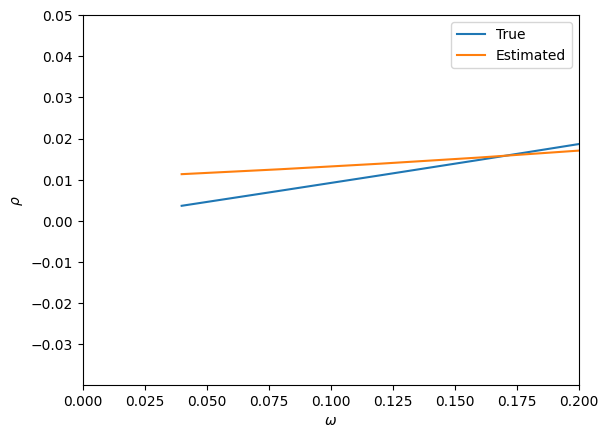

In [91]:
# Multfit result with 30 correlators
# rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,.2)
plt.ylim(None,0.05)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')


Text(0, 0.5, '$\\rho$')

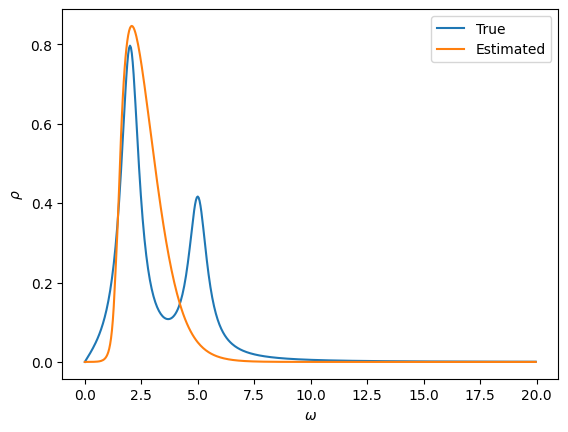

In [ ]:
# Multfit result with 30 correlators
# rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
# plt.xlim(0,.2)
# plt.ylim(None,0.05)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')


Text(0.5, 0, 'Epochs')

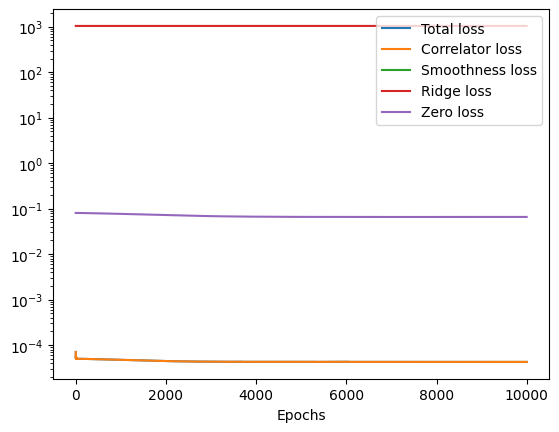

In [103]:
trainingepochs=range(10000)
trainingepochs30=range(30000)

loss_history=np.array(loss_history)
plt.figure()
plt.plot(total_loss_history,label=r'Total loss')
plt.plot(loss_history.T[0],label=r'Correlator loss')
plt.plot(loss_history.T[1],label=r'Smoothness loss')
plt.plot(loss_history.T[2],label=r'Ridge loss')
plt.plot(loss_history.T[3],label=r'Zero loss')

# plt.xlim(2500,3000)
plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

/tmp/ipykernel_30432/2963266323.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')
/tmp/ipykernel_30432/2963266323.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omega,np.squeeze(rho)/omega, label=r'Estimated',color='C1')


Text(0, 0.5, '$\\rho$')

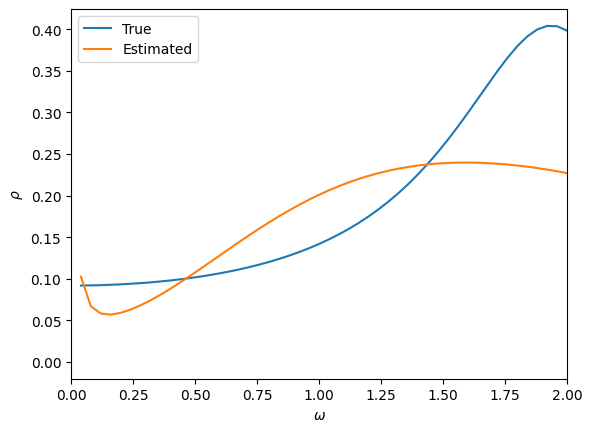

In [13]:
# Multfit result with 30 correlators
# rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho)/omega, label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')


/tmp/ipykernel_15328/3650129161.py:4: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')
/tmp/ipykernel_15328/3650129161.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omega,np.squeeze(rho)/omega, label=r'Trained $\rho$',color='C1')


Text(0, 0.5, '$\\rho/\\omega$')

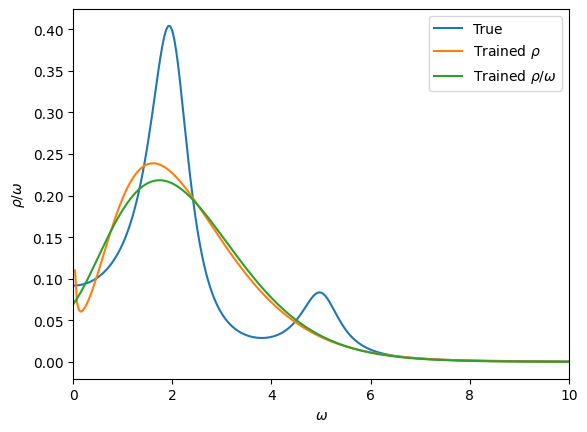

In [32]:
# Multfit result with 30 correlators
rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
rhoOmega=np.load('data/rho_Multifit_30_corrs.npy')
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho)/omega, label=r'Trained $\rho$',color='C1')
plt.plot(omega,np.squeeze(rhoOmega), label=r'Trained $\rho/\omega$',color='C2')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')

Text(0, 0.5, '$\\rho/\\omega$')

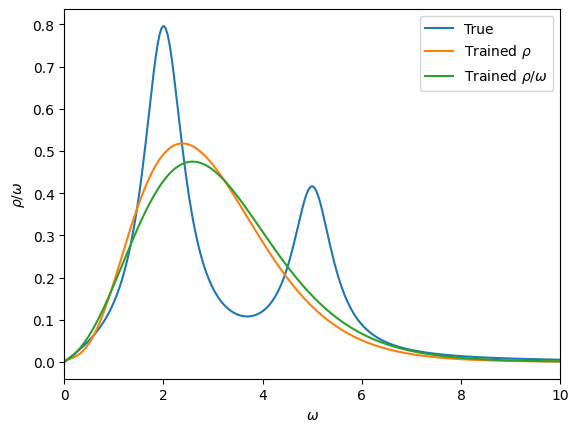

In [27]:
# Multfit result with 30 correlators
rho=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
rhoOmega=np.load('data/rho_Multifit_30_corrs.npy')
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Trained $\rho$',color='C1')
plt.plot(omega,np.squeeze(rhoOmega)*omega, label=r'Trained $\rho/\omega$',color='C2')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')

Text(0.5, 0, 'Epochs')

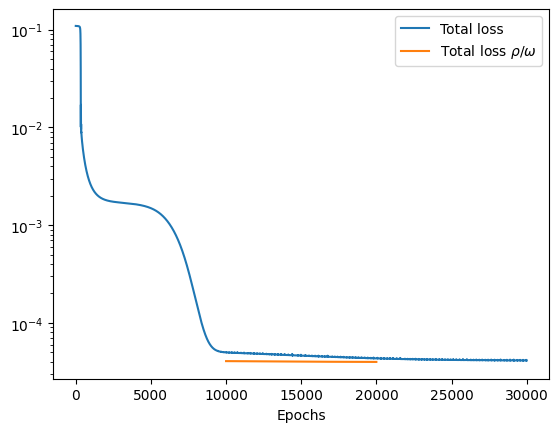

In [12]:
trainingepochs=range(10000)
trainingepochs30=range(30000)

total_loss_history_rhoFit=np.load('data/total_loss_history_Multifit_30_corrs_rhoFit.npy')
total_loss_history_rhoOmega=np.load('data/total_loss_history_Multifit_30_corrs.npy')

plt.figure()
plt.plot(total_loss_history_rhoFit,label=r'Total loss')
plt.plot(range(10000,20000),total_loss_history,label=r'Total loss $\rho/\omega$')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
# # plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

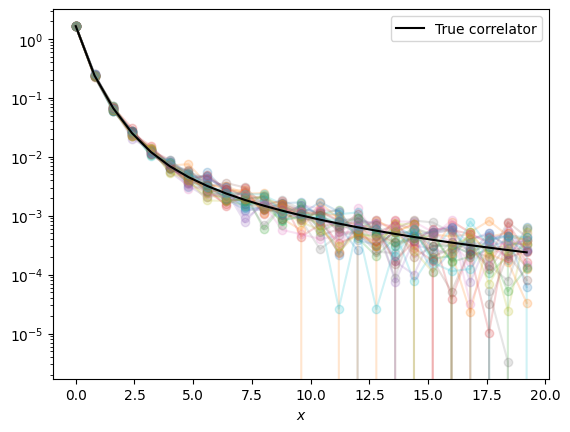

In [9]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.2,ls='-',marker='o')
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

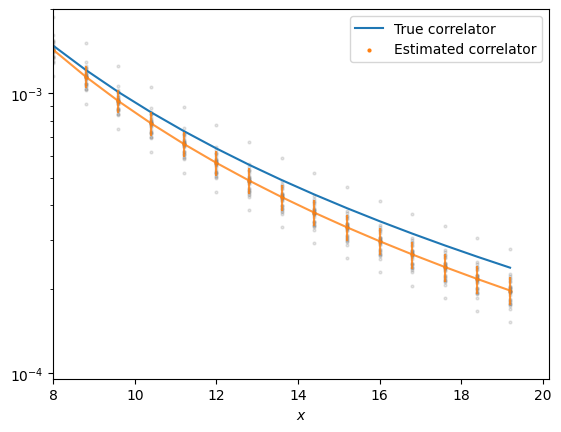

In [11]:
plt.plot(x,Dxi_ensemble[0], label=r'True correlator')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)
meanDxi=bootstrapMean(correlatorPredictions)
varDxi=bootstrapVariance(correlatorPredictions)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=0.8,color='C1')
plt.scatter(x,meanDxi, label=r'Estimated correlator',color='C1',s=4)
for i in range(num_samples):
    plt.scatter(x, correlatorPredictions[i], alpha=0.2, s=4,color='gray')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.xlim(8,None)
plt.ylim(None,2e-3)
plt.legend()
plt.show()

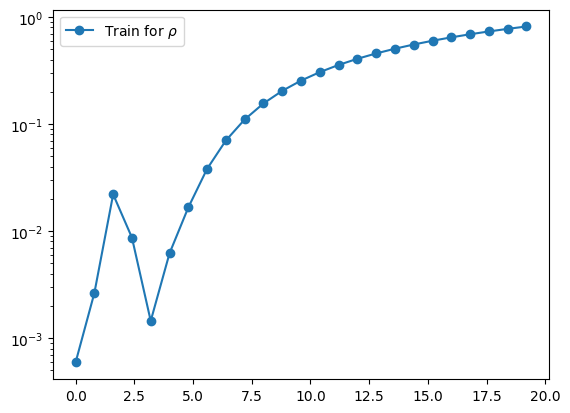

In [93]:
compareCorrelator=Dxi
DxiPred = correlator.Di(kl_ker_Pos,rho,del_omega)
plt.plot(x,np.abs(DxiPred-compareCorrelator)/compareCorrelator, label=r'Train for $\rho$',marker='o')
# plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

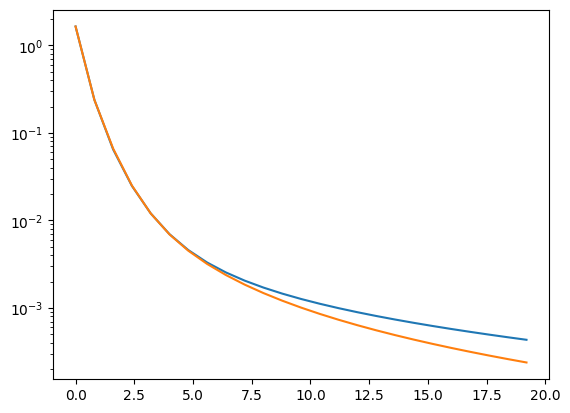

In [94]:
plt.plot(x,DxiPred, label=r'Predicted correlator')
plt.plot(x,compareCorrelator, label=r'True correlator')

plt.yscale('log')

# Behaviour of the kernal with $\omega$ and $p$.  

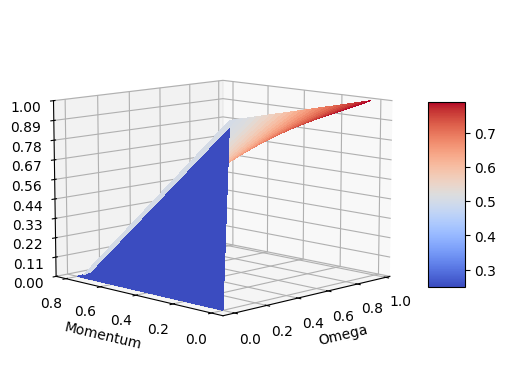

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [ ]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [ ]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [ ]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

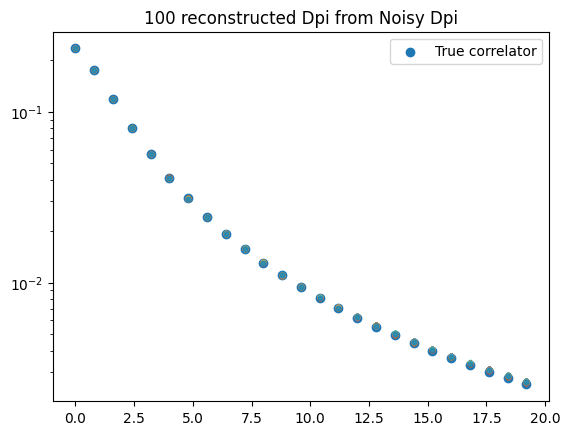

In [ ]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

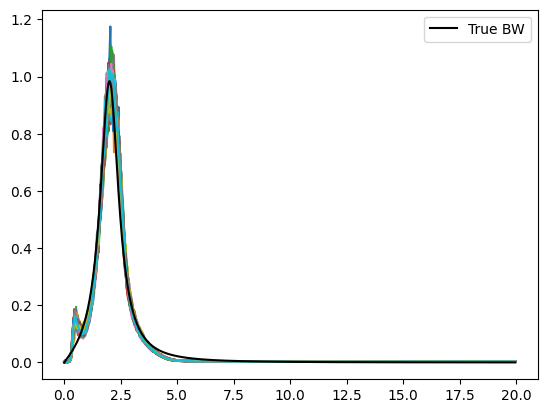

In [ ]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [ ]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [ ]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

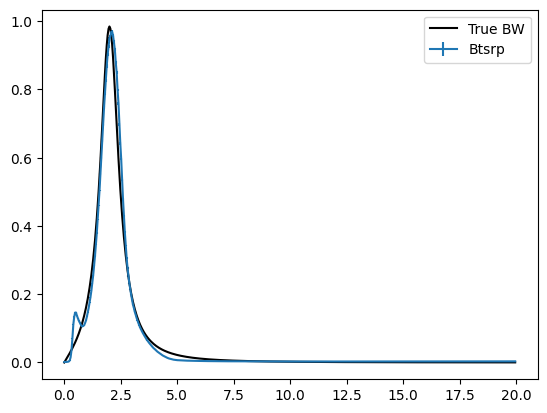

In [ ]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()